# jjh

---

**Project**
- CCRM

**Module**
- notebooks

**Author**
- Hyeok

**Created**
- 2026-03-07

**Purpose**
- TODO: EDA, Data Visualization

---


### 1. 설정 및 데이터 로드
이 부분은 데이터 분석의 '기초 공사'

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# 경고 무시 및 시각화 기본 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# [Why] 원본 데이터의 형태를 보존하면서 분석용 데이터프레임 생성
df = pd.read_csv('./data/preprocessed_BankChurners.csv')

# 데이터 로드 직후 행/열 개수 확인 (배포 시 데이터 유실 여부 체크)
print(f"Dataset Shape: {df.shape}")
df.head()

### 2. 변수 간 관계성 탐색 (Correlation)
상관계수는 모든 분석의 나침반 역할을 합니다.

In [ ]:
# [Why] 이탈(Churn)과 선형 관계가 높은 변수를 한눈에 파악
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 3. 범주형 변수 및 누락 데이터 분석

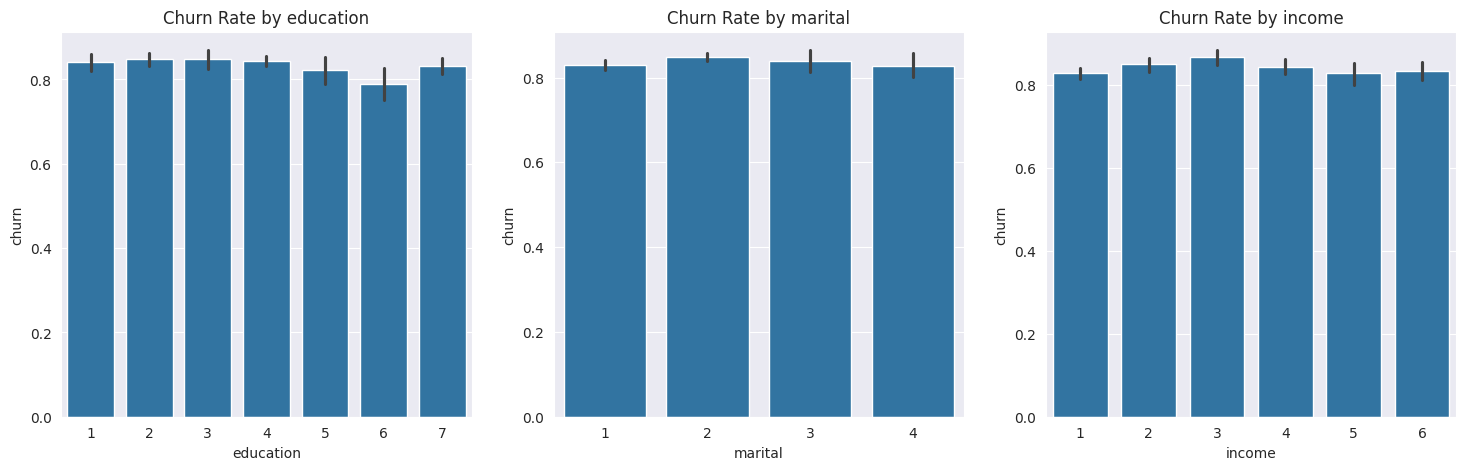

In [36]:
# [Why] 특정 정보가 누락된 고객(Unknown)이 이탈 위험군인지 검증
unknown_cols = ['education', 'marital', 'income']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(unknown_cols):
    sns.barplot(x=col, y='churn', data=df, ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')

In [ ]:
# [Why] 보유 카드 등급에 따른 고객 수와 이탈자 수의 절대량 파악
sns.countplot(x='card_type', hue='churn', data=df, palette='magma')
plt.title('Customer Count by Card Category')

### 4. 활동성 지표 심층 분석
이탈을 결정짓는 가장 핵심적인 '행동 데이터'를 분석

In [ ]:
# [Why] 이탈자와 유지자 간의 활동성 차이를 직관적으로 확인
sns.boxplot(x='churn', y='transaction_count', data=df)
plt.title('Transaction Count: Churn vs Loyal')

In [ ]:
# [Why] 연속형 데이터를 비즈니스에서 보고 가능한 '구간'으로 변환
bins = [0, 20, 40, 60, 80, 100, df['transaction_count'].max()]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100', '100+']
df['trans_ct_bin'] = pd.cut(df['transaction_count'], bins=bins, labels=labels)

In [ ]:
# [Why] 어느 구간에서 이탈률이 급증하는지 '골든 타임' 식별
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='trans_ct_bin', hue='churn', multiple='fill')
plt.ylabel('Churn Proportion')

### 5. 파생 변수 및 비즈니스 인사이트

Text(0.5, 1.0, 'Impact of Inactivity on Churn')

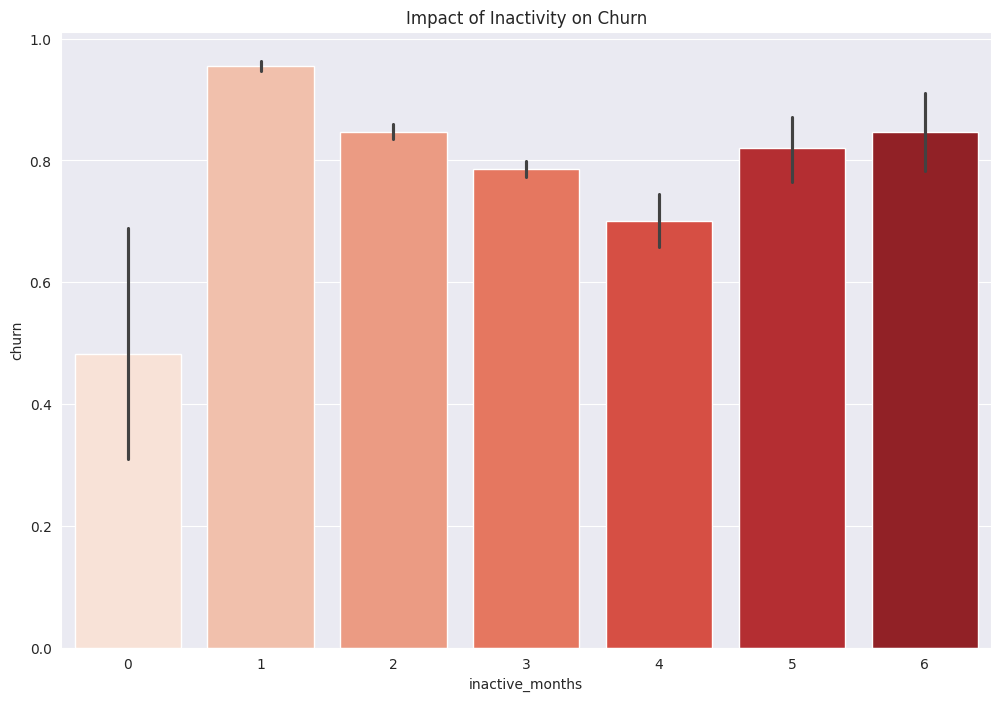

In [37]:
# [Why] 고객의 소비 효율성 변수 생성
df['amt_per_it'] = df['transaction_amount'] / df['transaction_count']

# 비활성 기간이 이탈에 미치는 영향 시각화
sns.barplot(x='inactive_months', y='churn', data=df, palette='Reds')
plt.title('Impact of Inactivity on Churn')

In [ ]:
# [Why] 카드 등급별로 이탈이 집중되는 거래 횟수 영역 확인
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='transaction_count', hue='card_type', weights='churn', fill=True)
plt.title('Churn Density by Card Type')

### 6. 가설 검정 및 데이터 내보내기

In [ ]:
# [Why] 시각화된 차이가 우연이 아님을 수학적으로 증명 (P-value 검증)
t_stat, p_val = stats.ttest_ind(df[df['churn']==0]['transaction_count'],
                                df[df['churn']==1]['transaction_count'])
print(f"P-value: {p_val:.4e}") # 0.05 미만이면 유의미

In [ ]:
# [Why] EDA를 통해 생성된 파생 변수(amt_per_it, trans_ct_bin 등)를 포함하여 저장
# 배포 팁: index=False를 설정해 데이터 로드 시 'Unnamed: 0' 컬럼 생성을 방지
df.to_csv('./data/df_after_eda.csv', index=False)
print("✅ EDA 데이터 저장 완료")